# Setup Path

In [10]:
import sys, os

project_root = os.path.abspath("..")
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Working directory:", os.getcwd())


Working directory: d:\Projects all\All GITHUB PROJECTS TO UPLOAD\Z FOLDERS OF ALL THE MAIN TOPICS\Computer_Vision\Road_Crack_Detection


# Imports

In [11]:
import torch
import cv2
import matplotlib.pyplot as plt
import torchvision.models as models   # ✅ this fixes the NameError

from src.train import train_model
from src.evaluate import load_model


# Train if Missing, Otherwise Load

In [12]:
model_path = "models/resnet18_crack.pth"

if not os.path.exists(model_path):
    print("⚠️ Model file not found. Training a new model...")
    # Build model
    net = models.resnet18(weights=None)
    net.fc = torch.nn.Linear(net.fc.in_features, 2)
    # Train and save
    train_model(net, epochs=2)
else:
    print("✅ Model file found:", model_path)

# Now load the model safely
net = load_model(model_path)


✅ Model file found: models/resnet18_crack.pth
✅ Model loaded from models/resnet18_crack.pth


# Prediction Function

In [13]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).float() / 255.0

    outputs = net(img_tensor)
    _, preds = torch.max(outputs, 1)
    label = "Crack" if preds.item() == 1 else "No Crack"

    plt.imshow(img)
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()

    return label


# Test Prediction

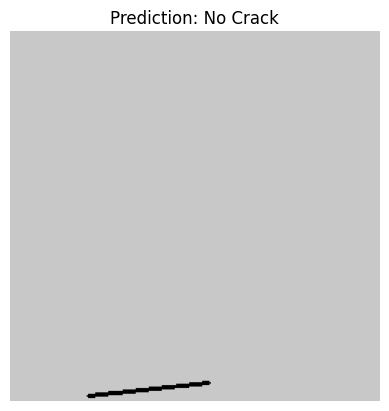

'No Crack'

In [14]:
predict_image("data/raw/road_0.png")
